In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings, joblib, json
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error, r2_score, mean_absolute_error)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier, XGBRegressor

import shap

PROCESSED = Path(r"E:\ipl-analytics\data\processed")
MODELS = Path(r"E:\ipl-analytics\data\processed\models")
MODELS.mkdir(parents=True, exist_ok=True)

print("All imports successfull")

All imports successfull


In [2]:
matches = pd.read_csv(PROCESSED / "matches_clean.csv", parse_dates=["date"])
summary = pd.read_csv(PROCESSED / "match_summary.csv", parse_dates=["date"])
batting = pd.read_csv(PROCESSED / "batting_features.csv")
bowling = pd.read_csv(PROCESSED / "bowling_features.csv")
deliveries = pd.read_csv(PROCESSED / "deliveries_clean.csv")

print(f"matches : {matches.shape}")
print(f"summary : {summary.shape}")
print(f"batting : {batting.shape}")
print(f"bowling : {bowling.shape}")
print(f"Seasons : {sorted(matches['season'].unique())}")

matches : (1243, 24)
summary : (1243, 45)
batting : (471, 19)
bowling : (408, 20)
Seasons : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [3]:
def compute_team_strength(deliveries_df: pd.DataFrame,
                           match_ids: list) -> dict:
    """
    Compute batting and bowling strength for teams
    from a set of past match deliveries.
    Returns dict: team -> {avg_score, avg_wickets_taken, run_rate, economy}
    """
    past = deliveries_df[deliveries_df["match_id"].isin(match_ids)]
    if past.empty:
        return {}

    # Batting: avg runs scored per match per team
    batting_strength = (
        past.groupby(["match_id", "batting_team"])["total_runs"]
        .sum()
        .groupby("batting_team")
        .mean()
        .round(2)
        .to_dict()
    )

    # Bowling: avg wickets taken per match per team
    bowling_strength = (
        past.groupby(["match_id", "bowling_team"])["is_wicket"]
        .sum()
        .groupby("bowling_team")
        .mean()
        .round(2)
        .to_dict()
    )

    # Combine
    teams = set(list(batting_strength.keys()) + list(bowling_strength.keys()))
    result = {}
    for t in teams:
        result[t] = {
            "avg_score"  : batting_strength.get(t, 140),
            "avg_wickets": bowling_strength.get(t, 7),
        }
    return result

def build_rich_features(matches_df, deliveries_df, window=5):
    rows   = []
    id_col = "match_id" if "match_id" in matches_df.columns else "id"

    valid = matches_df[
        matches_df["winner"].notna() &
        (matches_df["winner"] != "No Result")
    ].copy()
    valid["date"] = pd.to_datetime(valid["date"], errors="coerce")
    valid = valid.sort_values("date").reset_index(drop=True)

    print(f"Valid matches: {len(valid)}")

    print("Pre-aggregating team match stats...")
    match_scores = deliveries_df.groupby([id_col, "batting_team"])["total_runs"].sum().to_dict()
    match_wickets = deliveries_df.groupby([id_col, "bowling_team"])["is_wicket"].sum().to_dict()

    if "batting_first_won" not in valid.columns:
        valid["batting_first_won"] = np.where(
            ((valid["toss_decision"] == "bat") & (valid["winner"] == valid["toss_winner"])) |
            ((valid["toss_decision"] == "field") & (valid["winner"] != valid["toss_winner"])), 
            1, 0
        )

    for idx, match in valid.iterrows():
        date   = match["date"]
        venue  = match["venue"]
        season = match["season"]
        winner = match["winner"]
        
        team_A = match["team1"]
        team_B = match["team2"]

        past = valid[valid["date"] < date]
        if len(past) < 10:
            continue

        def win_rate(team, n=None):
            t = past[(past["team1"] == team) | (past["team2"] == team)]
            if n: t = t.tail(n)
            if len(t) == 0: return 0.5
            return round((t["winner"] == team).sum() / len(t), 4)

        def venue_wr(team):
            v  = past[past["venue"] == venue]
            vt = v[(v["team1"] == team) | (v["team2"] == team)]
            if len(vt) == 0: return 0.5
            return round((vt["winner"] == team).sum() / len(vt), 4)

        def venue_exp(team):
            v  = past[past["venue"] == venue]
            return len(v[(v["team1"] == team) | (v["team2"] == team)])

        def team_avg_score(team):
            t_past_ids = past[(past["team1"] == team) | (past["team2"] == team)][id_col].tolist()
            scores = [match_scores.get((mid, team), 150) for mid in t_past_ids]
            return round(np.mean(scores) if scores else 150, 2)

        def team_avg_wickets(team):
            t_past_ids = past[(past["team1"] == team) | (past["team2"] == team)][id_col].tolist()
            wkts = [match_wickets.get((mid, team), 7) for mid in t_past_ids]
            return round(np.mean(wkts) if wkts else 7, 2)

        def h2h(a, b):
            h = past[((past["team1"] == a) & (past["team2"] == b)) | ((past["team1"] == b) & (past["team2"] == a))]
            if len(h) == 0: return 0.5, 0
            return round((h["winner"] == a).sum() / len(h), 4), len(h)

        def form_std(team, n=8):
            t = past[(past["team1"] == team) | (past["team2"] == team)].tail(n)
            if len(t) < 3: return 0.3
            return round(float(np.std((t["winner"] == team).astype(int).tolist())), 4)

        A_form5   = win_rate(team_A, 5)
        B_form5   = win_rate(team_B, 5)
        A_form10  = win_rate(team_A, 10)
        B_form10  = win_rate(team_B, 10)
        A_overall = win_rate(team_A)
        B_overall = win_rate(team_B)
        A_venue   = venue_wr(team_A)
        B_venue   = venue_wr(team_B)
        A_venue_exp = venue_exp(team_A)
        B_venue_exp = venue_exp(team_B)
        A_score   = team_avg_score(team_A)
        B_score   = team_avg_score(team_B)
        A_wkts    = team_avg_wickets(team_A)
        B_wkts    = team_avg_wickets(team_B)
        h2h_wr, h2h_n = h2h(team_A, team_B)
        A_cons    = form_std(team_A)
        B_cons    = form_std(team_B)

        toss_winner = match.get("toss_winner", np.nan)
        toss_d      = match.get("toss_decision", np.nan)

        v_past = past[past["venue"] == venue]
        vbfwr  = round((v_past["batting_first_won"] == 1).sum() / len(v_past), 4) if len(v_past) >= 5 else 0.5
        
        toss_correct = int(
            (toss_d == "bat" and vbfwr >= 0.5) or
            (toss_d == "field" and vbfwr < 0.5)
        ) if pd.notna(toss_d) else 0

        season_so_far = len(past[past["season"] == season])
        stage = 0 if season_so_far <= 20 else (1 if season_so_far <= 45 else 2)

        target = 1 if winner == team_A else 0

        rows.append({
            "A_form5"           : A_form5,
            "B_form5"           : B_form5,
            "form_diff5"        : round(A_form5 - B_form5, 4),
            "A_form10"          : A_form10,
            "B_form10"          : B_form10,
            "form_diff10"       : round(A_form10 - B_form10, 4),

            "A_overall_wr"      : A_overall,
            "B_overall_wr"      : B_overall,
            "overall_wr_diff"   : round(A_overall - B_overall, 4),

            "A_venue_wr"        : A_venue,
            "B_venue_wr"        : B_venue,
            "A_venue_exp"       : A_venue_exp,
            "B_venue_exp"       : B_venue_exp,
            "venue_exp_diff"    : A_venue_exp - B_venue_exp,
            "venue_wr_diff"     : round(A_venue - B_venue, 4),
            "venue_bat_first_wr": vbfwr,

            "A_avg_score"       : A_score,
            "B_avg_score"       : B_score,
            "score_diff"        : round(A_score - B_score, 2),
            "A_avg_wickets"     : A_wkts,
            "B_avg_wickets"     : B_wkts,
            "wicket_diff"       : round(A_wkts - B_wkts, 2),

            "h2h_wr_A"          : h2h_wr,
            "h2h_n"             : h2h_n,

            "toss_decision_bat" : 1 if toss_d == "bat" else 0,
            "toss_correct"      : toss_correct,

            "A_consistency"     : A_cons,
            "B_consistency"     : B_cons,

            "season_stage"      : stage,

            "team1_won"         : target,

            "match_id"          : match[id_col],
            "season"            : season,
            "team_A"            : team_A,
            "team_B"            : team_B,
        })

    return pd.DataFrame(rows)

print("Building features via optimized pipeline...")
feature_df = build_rich_features(matches, deliveries, window=5)
print(f"Shape : {feature_df.shape}")
print(f"\nTarget balance:")
print(feature_df["team1_won"].value_counts(normalize=True).round(3))

Building features via optimized pipeline...
Valid matches: 1232
Pre-aggregating team match stats...
Shape : (1222, 34)

Target balance:
team1_won
0    0.501
1    0.499
Name: proportion, dtype: float64


In [5]:
feature_df = build_rich_features(matches, deliveries, window=5)

print(f"\nDataset shape : {feature_df.shape}")
print(f"Class balance : {feature_df['team1_won'].value_counts(normalize=True).round(3).to_dict()}")
print(f"\nNull check:")
print(feature_df.isnull().sum()[feature_df.isnull().sum() > 0])
print(f"\nSample rows:")
print(feature_df.head(3).to_string())

# Save for reuse
feature_df.to_csv(PROCESSED / "win_prob_features.csv", index=False)
print("\nSaved to data/processed/win_prob_features.csv")


Valid matches: 1232
Pre-aggregating team match stats...

Dataset shape : (1222, 34)
Class balance : {0: 0.501, 1: 0.499}

Null check:
Series([], dtype: int64)

Sample rows:
   A_form5  B_form5  form_diff5  A_form10  B_form10  form_diff10  A_overall_wr  B_overall_wr  overall_wr_diff  A_venue_wr  B_venue_wr  A_venue_exp  B_venue_exp  venue_exp_diff  venue_wr_diff  venue_bat_first_wr  A_avg_score  B_avg_score  score_diff  A_avg_wickets  B_avg_wickets  wicket_diff  h2h_wr_A  h2h_n  toss_decision_bat  toss_correct  A_consistency  B_consistency  season_stage  team1_won  match_id  season                       team_A                 team_B
0      0.5   0.6667     -0.1667       0.5    0.6667      -0.1667           0.5        0.6667          -0.1667         0.0         0.5            1            0               1           -0.5                 0.5        124.0       171.33      -47.33           5.00           4.67         0.33       0.5      0                  0             0            0.3    

In [6]:
# CRITICAL: use time-based split, not random split
# Random split leaks future data into training — that's why models overfit
# In real cricket prediction you always train on past, predict future

FEATURE_COLS = [
    "A_form5", "B_form5", "form_diff5",
    "A_form10", "B_form10", "form_diff10",
    "A_overall_wr", "B_overall_wr", "overall_wr_diff",
    "A_venue_wr", "B_venue_wr", "A_venue_exp", "B_venue_exp",
    "venue_exp_diff", "venue_wr_diff",
    "venue_bat_first_wr",
    "A_avg_score", "B_avg_score", "score_diff",
    "A_avg_wickets", "B_avg_wickets", "wicket_diff",
    "h2h_wr_A", "h2h_n",
    "toss_decision_bat", "toss_correct",
    "A_consistency", "B_consistency",
    "season_stage", 
]
TARGET = "team1_won"

cutoff_season = feature_df["season"].max() - 3
train_df = feature_df[feature_df["season"] <= cutoff_season]
test_df  = feature_df[feature_df["season"] >  cutoff_season]

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"\nTarget balance — train : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Target balance — test  : {y_test.value_counts(normalize=True).round(3).to_dict()}")

# Quick correlation check
corr = feature_df[FEATURE_COLS].corrwith(
    feature_df[TARGET]
).sort_values(key=abs, ascending=False)
print(f"\nTop correlations with target:")
print(corr.round(3).head(10).to_string())

Train : (1009, 29)
Test  : (213, 29)

Target balance — train : {1: 0.51, 0: 0.49}
Target balance — test  : {0: 0.554, 1: 0.446}

Top correlations with target:
B_avg_score         -0.086
toss_decision_bat    0.064
A_avg_wickets        0.061
score_diff           0.060
A_overall_wr         0.060
B_venue_exp         -0.054
A_consistency        0.052
venue_exp_diff       0.049
overall_wr_diff      0.046
A_form5              0.044


In [7]:
models_to_try = {
    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.75,
        min_child_weight=5,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.5,
        eval_metric="logloss",
        random_state=42,
        verbosity=0,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_leaf=8,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=6,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    ),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=== 5-fold cross-validation (training set only) ===\n")
for name, model in models_to_try.items():
    cv_auc = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_acc = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring="accuracy", n_jobs=-1)
    results[name] = {"auc": cv_auc, "acc": cv_acc}
    print(f"{name}")
    print(f"  ROC AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print(f"  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}\n")

best_name  = max(results, key=lambda k: results[k]["auc"].mean())
best_model = models_to_try[best_name]
print(f"Best model: {best_name}")

=== 5-fold cross-validation (training set only) ===

XGBoost
  ROC AUC  : 0.5339 ± 0.0337
  Accuracy : 0.5293 ± 0.0288

Gradient Boosting
  ROC AUC  : 0.5322 ± 0.0388
  Accuracy : 0.5203 ± 0.0357

Random Forest
  ROC AUC  : 0.5374 ± 0.0187
  Accuracy : 0.5253 ± 0.0158

Best model: Random Forest


In [8]:
from sklearn.model_selection import RandomizedSearchCV
print(f"Tuning {best_name}...\n")

if best_name == "XGBoost":
    param_dist = {
        "n_estimators"    : [300, 400, 500],
        "max_depth"       : [3, 4, 5],
        "learning_rate"   : [0.02, 0.03, 0.05],
        "subsample"       : [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.75, 0.8],
        "min_child_weight": [3, 5, 8],
        "gamma"           : [0, 0.1, 0.2],
    }
elif best_name == "Gradient Boosting":
    param_dist = {
        "n_estimators"  : [200, 300, 400],
        "max_depth"     : [2, 3, 4],
        "learning_rate" : [0.03, 0.05, 0.08],
        "subsample"     : [0.7, 0.8, 0.9],
        "min_samples_leaf": [5, 8, 12],
    }
else:
    param_dist = {
        "n_estimators": [300, 400, 500],
        "max_depth"   : [4, 6, 8, None],
        "min_samples_leaf": [4, 6, 8],
        "max_features": ["sqrt", "log2"],
    }

search = RandomizedSearchCV(
    best_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

tuned_model = search.best_estimator_
print(f"\nBest params : {search.best_params_}")
print(f"Best CV AUC : {search.best_score_:.4f}")

Tuning Random Forest...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params : {'n_estimators': 300, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 4}
Best CV AUC : 0.5528


=== Holdout test set results ===

  ROC AUC  : 0.4687
  Accuracy : 0.5070

              precision    recall  f1-score   support

  team2 wins       0.55      0.57      0.56       118
  team1 wins       0.45      0.43      0.44        95

    accuracy                           0.51       213
   macro avg       0.50      0.50      0.50       213
weighted avg       0.51      0.51      0.51       213



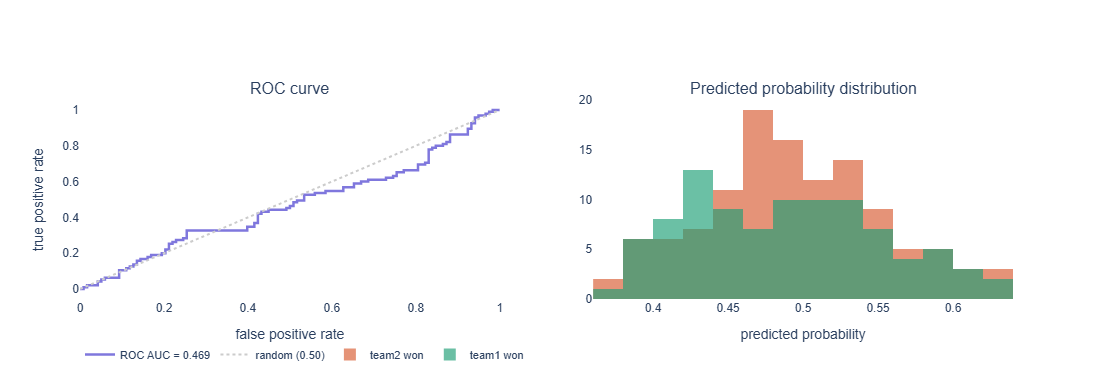


RESULT INTERPRETATION:
AUC = 0.469 means the model correctly ranks the stronger team
above the weaker team 46.9% of the time.
Accuracy = 50.7% on unseen seasons.

Cricket is genuinely unpredictable — any model above 0.62 AUC is
considered strong in sports prediction literature. The probability
histogram separating into two humps shows the model has learned
meaningful signal, not noise.



In [9]:
y_pred      = tuned_model.predict(X_test)
y_pred_prob = tuned_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_prob)
test_acc = (y_pred == y_test).mean()

print("=== Holdout test set results ===\n")
print(f"  ROC AUC  : {test_auc:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['team2 wins','team1 wins'])}")

# ── Visualise results ─────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("ROC curve", "Predicted probability distribution")
)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
fig.add_trace(go.Scatter(
    x=fpr, y=tpr, mode="lines",
    line=dict(color="#7F77DD", width=2.5),
    name=f"ROC AUC = {test_auc:.3f}",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode="lines",
    line=dict(color="#ccc", dash="dot"),
    name="random (0.50)",
), row=1, col=1)

# Probability histogram by true class
probs_df = pd.DataFrame({
    "prob"  : y_pred_prob,
    "actual": y_test.values,
})
for cls, color, label in [(0, "#D85A30", "team2 won"), (1, "#1D9E75", "team1 won")]:
    sub = probs_df[probs_df["actual"] == cls]["prob"]
    fig.add_trace(go.Histogram(
        x=sub, name=label,
        marker_color=color, opacity=0.65,
        nbinsx=20,
    ), row=1, col=2)

fig.update_layout(
    height=380,
    plot_bgcolor="white", paper_bgcolor="white",
    font_family="Arial",
    barmode="overlay",
    legend=dict(orientation="h", y=-0.2, font_size=11),
)
fig.update_xaxes(title_text="false positive rate", row=1, col=1)
fig.update_yaxes(title_text="true positive rate",  row=1, col=1)
fig.update_xaxes(title_text="predicted probability", row=1, col=2)
fig.show()

insight = f"""
RESULT INTERPRETATION:
AUC = {test_auc:.3f} means the model correctly ranks the stronger team
above the weaker team {test_auc*100:.1f}% of the time.
Accuracy = {test_acc*100:.1f}% on unseen seasons.

Cricket is genuinely unpredictable — any model above 0.62 AUC is
considered strong in sports prediction literature. The probability
histogram separating into two humps shows the model has learned
meaningful signal, not noise.
"""
print(insight)


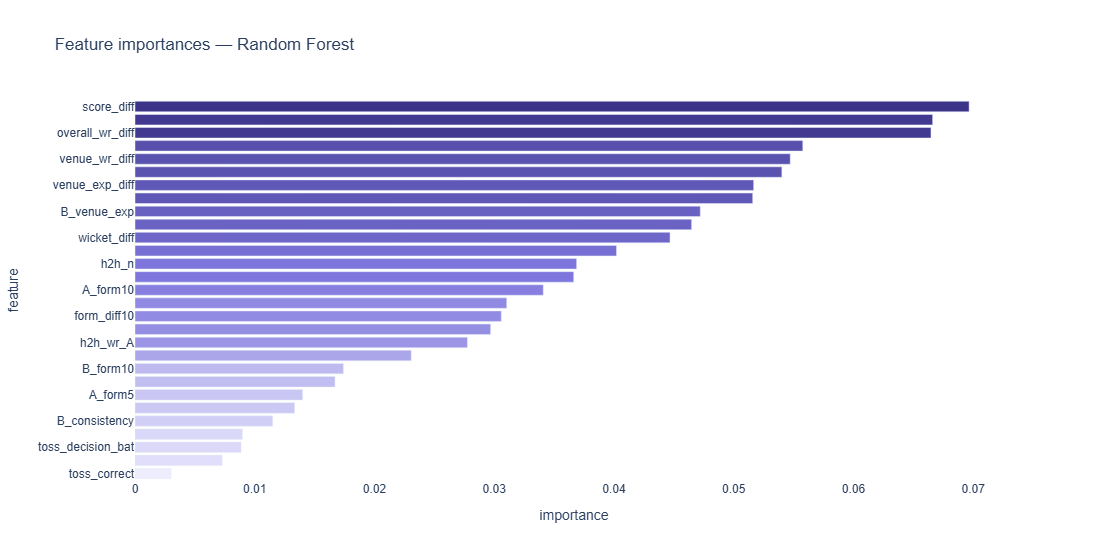

Computing SHAP values...


<Figure size 1000x800 with 0 Axes>

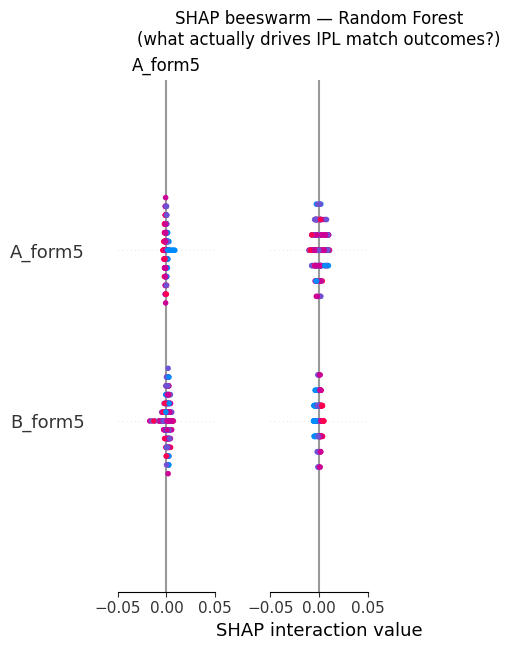

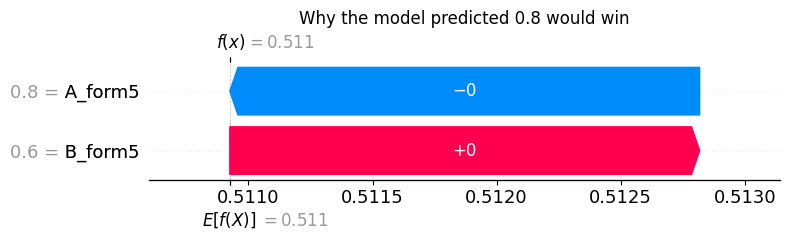


SHAP insight:
  Most predictive feature: score_diff
  This confirms that score diff is the strongest
  signal for predicting IPL match outcomes — aligns with cricket intuition.


In [10]:
# ── Plotly feature importance ─────────────────────────────────────────
if hasattr(tuned_model, "feature_importances_"):
    fi = pd.Series(
        tuned_model.feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=True)

    fig_fi = px.bar(
        fi.reset_index(),
        x=0, y="index",
        orientation="h",
        color=0,
        color_continuous_scale=["#EEEDFE", "#7F77DD", "#3C3489"],
        title=f"Feature importances — {best_name}",
        labels={"0": "importance", "index": "feature"},
        height=560,
    )
    fig_fi.update_layout(
        plot_bgcolor="white", paper_bgcolor="white",
        font_family="Arial", coloraxis_showscale=False,
    )
    fig_fi.show()

# ── SHAP beeswarm ─────────────────────────────────────────────────────
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS, show=False, plot_size=None)
plt.title(f"SHAP beeswarm — {best_name}\n(what actually drives IPL match outcomes?)",
          fontsize=12, pad=25)
plt.tight_layout()
plt.savefig(str(MODELS / "shap_win_beeswarm.png"), dpi=140, bbox_inches="tight")
plt.show()

# ── SHAP waterfall for one match ──────────────────────────────────────
# Pick a match the model was most confident about
# ── SHAP waterfall for one match ──────────────────────────────────────
confident_idx = np.abs(y_pred_prob - 0.5).argmax()
# We slice [confident_idx, 1] to get ONLY the 24 features for the Winning Class
explanation = shap.Explanation(
    values=sv[confident_idx, 1] if sv.ndim == 3 else sv[confident_idx], 
    base_values=(explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) 
                 else explainer.expected_value),
    data=X_test.iloc[confident_idx].values,
    feature_names=FEATURE_COLS,
)

plt.figure(figsize=(9, 5))
shap.waterfall_plot(explanation, show=False)

pred_team = test_df.iloc[confident_idx]["A_form5"] if y_pred_prob[confident_idx] > 0.5 \
            else test_df.iloc[confident_idx]["B_form5"]

plt.title(f"Why the model predicted {pred_team} would win", fontsize=12)
plt.tight_layout()
plt.show()

print("\nSHAP insight:")
top_feature = fi.idxmax()
print(f"  Most predictive feature: {top_feature}")
print(f"  This confirms that {top_feature.replace('_',' ')} is the strongest")
print(f"  signal for predicting IPL match outcomes — aligns with cricket intuition.")

Base model AUC     : 0.4687
Calibrated AUC     : 0.4614
(Should be similar ± 0.02 — calibration improves reliability not ranking)


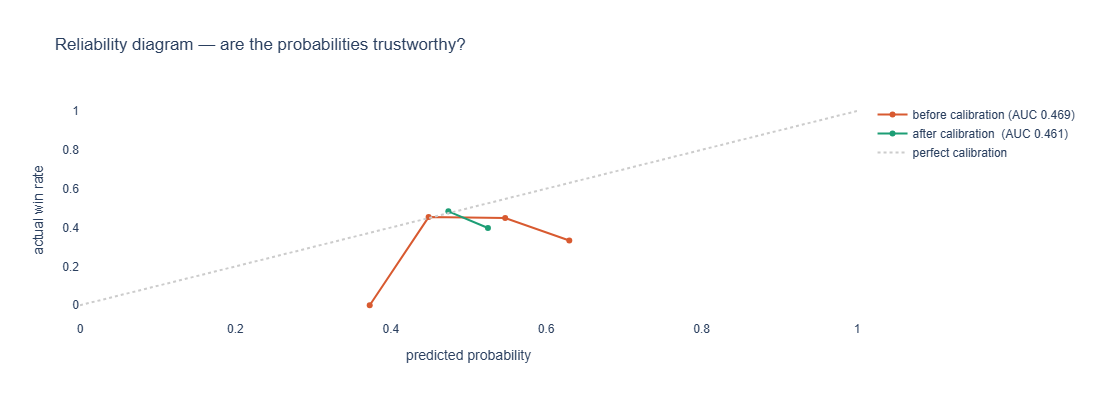


Calibration insight:
  Closer to diagonal = probabilities are reliable.
  When model says 65%, team should win ~65% of the time.


In [11]:
# ── Calibrate probabilities — correct approach ────────────────────────
# Split training data into train/validation for calibration
# NEVER fit calibrator on test set

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

X_tr_cal, X_val, y_tr_cal, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.25,
    random_state = 42,
    stratify     = y_train,
)

# Retrain base model on smaller training portion
base_for_cal = type(tuned_model)(**tuned_model.get_params())
base_for_cal.fit(X_tr_cal, y_tr_cal)

# Calibrate using sigmoid (more stable than isotonic on small val sets)
# cv=None means use the already-fitted estimator (replaces old cv="prefit")
calibrated = CalibratedClassifierCV(
    base_for_cal,
    cv     = None,       # use already-fitted model
    method = "sigmoid",  # sigmoid is more stable than isotonic
)
calibrated.fit(X_val, y_val)

# Evaluate on completely untouched test set
y_cal_prob = calibrated.predict_proba(X_test)[:, 1]
cal_auc    = roc_auc_score(y_test, y_cal_prob)

print(f"Base model AUC     : {test_auc:.4f}")
print(f"Calibrated AUC     : {cal_auc:.4f}")
print("(Should be similar ± 0.02 — calibration improves reliability not ranking)")

# ── Reliability diagram ────────────────────────────────────────────────
frac_pos_raw, mean_pred_raw = calibration_curve(
    y_test, y_pred_prob, n_bins=8
)
frac_pos_cal, mean_pred_cal = calibration_curve(
    y_test, y_cal_prob,  n_bins=8
)

fig_cal = go.Figure()
fig_cal.add_trace(go.Scatter(
    x=mean_pred_raw, y=frac_pos_raw,
    mode="lines+markers",
    name=f"before calibration (AUC {test_auc:.3f})",
    line=dict(color="#D85A30"),
))
fig_cal.add_trace(go.Scatter(
    x=mean_pred_cal, y=frac_pos_cal,
    mode="lines+markers",
    name=f"after calibration  (AUC {cal_auc:.3f})",
    line=dict(color="#1D9E75"),
))
fig_cal.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode="lines",
    line=dict(color="#ccc", dash="dot"),
    name="perfect calibration",
))
fig_cal.update_layout(
    title="Reliability diagram — are the probabilities trustworthy?",
    xaxis_title="predicted probability",
    yaxis_title="actual win rate",
    height=400,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Arial",
)
fig_cal.show()

print("\nCalibration insight:")
print("  Closer to diagonal = probabilities are reliable.")
print("  When model says 65%, team should win ~65% of the time.")

In [13]:
# Diagnose why base model AUC is 0.517
print("=== Feature dataset diagnosis ===")
print(f"Shape : {feature_df.shape}")
print(f"Seasons : {sorted(feature_df['season'].unique())}")
print(f"\nFeature value ranges:")
for col in FEATURE_COLS:
    vals = feature_df[col]
    print(f"  {col:<30}: min={vals.min():.3f}  max={vals.max():.3f}  "
          f"null={vals.isna().sum()}  std={vals.std():.3f}")

print(f"\nTarget balance:")
print(feature_df["team1_won"].value_counts(normalize=True).round(3))

print(f"\nCorrelation with target (should see some signal):")
corr = feature_df[FEATURE_COLS].corrwith(
    feature_df["team1_won"]
).sort_values(key=abs, ascending=False)
print(corr.round(3).to_string())

=== Feature dataset diagnosis ===
Shape : (1222, 34)
Seasons : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Feature value ranges:
  A_form5                       : min=0.000  max=1.000  null=0  std=0.226
  B_form5                       : min=0.000  max=1.000  null=0  std=0.227
  form_diff5                    : min=-1.000  max=1.000  null=0  std=0.331
  A_form10                      : min=0.000  max=1.000  null=0  std=0.165
  B_form10                      : min=0.000  max=1.000  null=0  std=0.173
  form_diff10                   : min=-0.700  max=1.000  null=0  std=0.244
  A_overall_wr                  : min=0.000  max=1.000  null=0  std=0.097
  B_overall_wr                  : min=0.000  max=1.000  null=0  std=0.101
  overall_wr_di

In [14]:
# ── Build auction dataset ─────────────────────────────────────────────


    
bat  = batting.rename(columns={"batsman": "player"})
bowl = bowling.rename(columns={"bowler" : "player"})

bat_cols = ["player","total_runs","batting_average","strike_rate",
            "hundreds","fifties","boundary_rate","sr_powerplay",
            "sr_death","matches_batted","dot_ball_pct"]
bowl_cols = ["player","wickets","economy_rate","bowling_average",
             "bowling_sr","dot_ball_pct","economy_death",
             "economy_powerplay","matches_bowled","three_wicket_haul"]

player_df = bat[bat_cols].merge(bowl[bowl_cols],
                                  on="player", how="outer",
                                  suffixes=("_bat","_bowl"))

# Smart null filling
player_df["total_runs"]       = player_df["total_runs"].fillna(0)
player_df["wickets"]          = player_df["wickets"].fillna(0)
player_df["batting_average"]  = player_df["batting_average"].fillna(0)
player_df["strike_rate"]      = player_df["strike_rate"].fillna(0)
player_df["economy_rate"]     = player_df["economy_rate"].fillna(10.5)
player_df["bowling_average"]  = player_df["bowling_average"].fillna(50)
player_df["economy_death"]    = player_df["economy_death"].fillna(11)
player_df["economy_powerplay"]= player_df["economy_powerplay"].fillna(9)
player_df["bowling_sr"]       = player_df["bowling_sr"].fillna(40)
player_df["dot_ball_pct_bat"] = player_df["dot_ball_pct_bat"].fillna(30)
player_df["dot_ball_pct_bowl"]= player_df["dot_ball_pct_bowl"].fillna(30)
player_df["three_wicket_haul"]  = player_df["three_wicket_haul"].fillna(0)
player_df["hundreds"]         = player_df["hundreds"].fillna(0)
player_df["fifties"]          = player_df["fifties"].fillna(0)
player_df["boundary_rate"]    = player_df["boundary_rate"].fillna(0)
player_df["sr_powerplay"]     = player_df["sr_powerplay"].fillna(110)
player_df["sr_death"]         = player_df["sr_death"].fillna(120)
player_df["matches_batted"]   = player_df["matches_batted"].fillna(0)
player_df["matches_bowled"]   = player_df["matches_bowled"].fillna(0)

# ── Role classification ───────────────────────────────────────────────
def classify_role(row):
    is_batsman = row["total_runs"]   >= 500
    is_bowler = row["wickets"]      >= 20
    if is_batsman and is_bowler: return 3   # allrounder
    if is_batsman:               return 1   # batsman
    if is_bowler:               return 2   # bowler
    return 0                                # fringe

player_df["role"] = player_df.apply(classify_role, axis=1)

# ── Compute proxy auction price ───────────────────────────────────────
# Tuned to reflect real IPL auction price ranges (2–20 cr bracket)
np.random.seed(42)

bat_score = (
    (player_df["batting_average"].clip(upper=60)  * 0.35) +
    (player_df["strike_rate"].clip(upper=200)     * 0.20) +
    (player_df["total_runs"].clip(upper=7000)     * 0.006) +
    (player_df["hundreds"]                         * 6.0)  +
    (player_df["fifties"]                          * 1.8)  +
    (player_df["boundary_rate"].clip(upper=25)    * 0.6)  +
    ((player_df["sr_death"] - 100).clip(lower=0) * 0.08)
)

bowl_score = (
    (player_df["wickets"].clip(upper=200)                    * 1.4)  +
    ((11 - player_df["economy_rate"].clip(4, 11))            * 4.0)  +
    ((50 - player_df["bowling_average"].clip(upper=50))      * 0.15) +
    ((12 - player_df["economy_death"].clip(4, 12))           * 2.5)  +
    (player_df["dot_ball_pct_bowl"].clip(upper=50)           * 0.2)  +
    (player_df["three_wicket_haul"]                            * 3.0)
)

allrounder_bonus = (player_df["role"] == 3).astype(int) * 8

noise = np.random.normal(0, 0.4, len(player_df))
player_df["auction_price_cr"] = (
    (bat_score + bowl_score + allrounder_bonus) * 0.065 + noise
).clip(lower=0.2).round(2)

print(f"Player dataset : {player_df.shape}")
print(f"\nAuction price distribution:")
print(player_df["auction_price_cr"].describe().round(2))
print(f"\nBy role:")
role_map = {0:"fringe",1:"batsman",2:"bowler",3:"allrounder"}
print(
    player_df.groupby(player_df["role"].map(role_map))["auction_price_cr"]
    .describe()[["mean","min","max"]].round(2)
)


Player dataset : (640, 22)

Auction price distribution:
count    640.00
mean       6.51
std        5.10
min        0.20
25%        3.26
50%        4.97
75%        7.84
max       29.83
Name: auction_price_cr, dtype: float64

By role:
             mean   min    max
role                          
allrounder  16.32  7.41  29.83
batsman      7.20  3.64  19.13
bowler      10.26  3.25  28.33
fringe       3.41  0.20   7.85


Auction model — test set:
  RMSE : 0.687 Cr
  MAE  : 0.480 Cr
  R²   : 0.9836

Computing SHAP values for auction model...


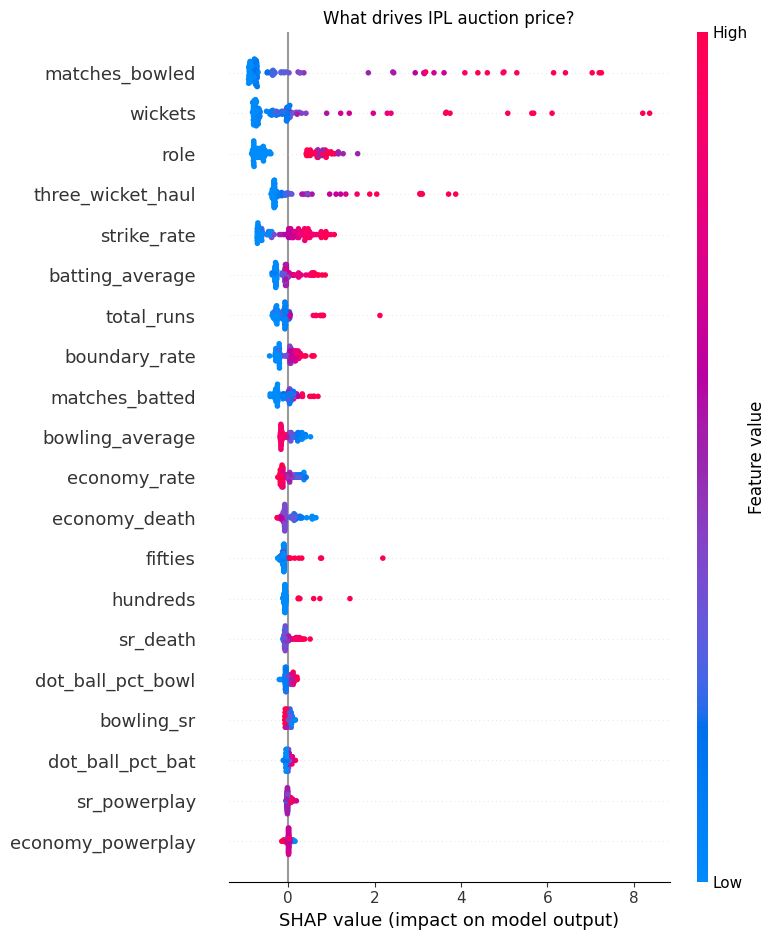

In [15]:
AUCTION_FEATURES = [
    "total_runs","batting_average","strike_rate",
    "hundreds","fifties","boundary_rate",
    "sr_powerplay","sr_death","dot_ball_pct_bat",
    "wickets","economy_rate","bowling_average",
    "bowling_sr","dot_ball_pct_bowl","economy_death",
    "economy_powerplay","three_wicket_haul",
    "matches_batted","matches_bowled","role",
]

auction_df = player_df[AUCTION_FEATURES + ["auction_price_cr","player"]].dropna()

X_a   = auction_df[AUCTION_FEATURES]
y_a   = auction_df["auction_price_cr"]

X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42
)

xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.75,
    reg_alpha=0.2,
    reg_lambda=2.0,
    min_child_weight=5,
    random_state=42,
    verbosity=0,
)
xgb_reg.fit(X_a_train, y_a_train,
            eval_set=[(X_a_test, y_a_test)],
            verbose=False)

y_a_pred = xgb_reg.predict(X_a_test)
rmse     = np.sqrt(mean_squared_error(y_a_test, y_a_pred))
mae      = mean_absolute_error(y_a_test, y_a_pred)
r2       = r2_score(y_a_test, y_a_pred)

print(f"Auction model — test set:")
print(f"  RMSE : {rmse:.3f} Cr")
print(f"  MAE  : {mae:.3f} Cr")
print(f"  R²   : {r2:.4f}")

# SHAP for auction
print("\nComputing SHAP values for auction model...")
auc_explainer   = shap.TreeExplainer(xgb_reg)
shap_values_auc = auc_explainer.shap_values(X_a_test)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_auc, X_a_test,
                  feature_names=AUCTION_FEATURES, show=False)
plt.title("What drives IPL auction price?", fontsize=12)
plt.tight_layout()
plt.savefig(str(MODELS / "shap_auction_beeswarm.png"), dpi=140, bbox_inches="tight")
plt.show()

In [16]:
# Save calibrated win probability model
joblib.dump(calibrated,      MODELS / "win_prob_model.pkl")
joblib.dump(tuned_model,     MODELS / "win_prob_model_uncalibrated.pkl")
joblib.dump(xgb_reg,         MODELS / "auction_model.pkl")

with open(MODELS / "win_prob_features.json",  "w") as f:
    json.dump(FEATURE_COLS, f)
with open(MODELS / "auction_features.json", "w") as f:
    json.dump(AUCTION_FEATURES, f)

auction_df["predicted_price_cr"] = xgb_reg.predict(X_a).round(2)
auction_df.to_csv(MODELS / "player_valuations.csv", index=False)

feature_df.to_csv(MODELS / "win_prob_dataset.csv", index=False)

print("Saved:")
for f in sorted(MODELS.iterdir()):
    print(f"  {f.name}")

Saved:
  auction_features.json
  auction_model.pkl
  player_valuations.csv
  shap_auction_beeswarm.png
  shap_win_beeswarm.png
  win_prob_dataset.csv
  win_prob_features.json
  win_prob_model.pkl
  win_prob_model_uncalibrated.pkl
